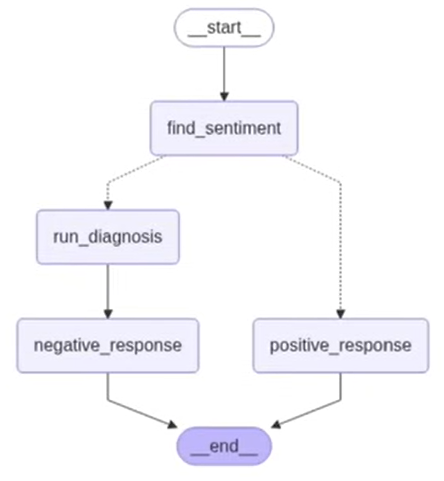

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model='gpt-4o-mini')

In [9]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')



class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')


In [10]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [11]:
prompt = 'What is the sentiment of the following review - The software too bad'
structured_model2.invoke(prompt)

DiagnosisSchema(issue_type='Other', tone='disappointed', urgency='medium')

In [12]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [13]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

In [14]:
def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    
    response = model.invoke(prompt).content

    return {'response': response}

In [15]:
def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

In [16]:
def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [17]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

In [18]:
graph = StateGraph(ReviewState)

# add nodes
graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

# add edges with conditions
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

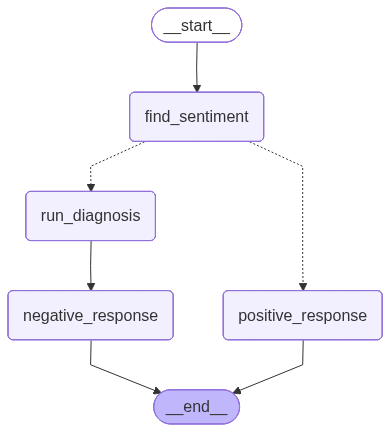

In [19]:
workflow

In [20]:
intial_state={
    'review': "Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!"
}
result = workflow.invoke(intial_state)

In [21]:
result

{'review': 'Excellent software with a clean interface and smooth performance. It has improved our workflow significantly and saved a lot of time. Highly recommended for anyone looking for a reliable tech solution!',
 'sentiment': 'positive',
 'response': "Dear [User's Name],\n\nThank you so much for your wonderful review! We're thrilled to hear that our software has made such a positive impact on your workflow and has helped save you time. Your kind words motivate us to keep improving and providing a reliable solution for our users.\n\nIf you have a moment, we'd greatly appreciate it if you could leave your feedback on our website as well. It would mean a lot to us and help others in their decision-making process.\n\nThanks again for your support!\n\nWarm regards,  \n[Your Name]  \n[Your Position]  \n[Your Company]  "}

In [22]:
intial_state={
    'review': "The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement."
}
result = workflow.invoke(intial_state)

In [23]:
result

{'review': 'The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'frustrated',
  'urgency': 'high'},
 'response': "Subject: We're Here to Help You with the Performance Issue\n\nHi [User's Name],\n\nI truly understand how frustrating it can be when you're experiencing performance issues, especially when you're relying on your system to work efficiently. I want to assure you that I’m here to help you resolve this as quickly as possible.\n\nCould you please provide a few more details about the issue you're facing? Specifically, if you could describe what you were doing when the performance lags occurred, any error messages you may have received, and the specifications of your system, that would be incredibly helpful.\n\nIn the meantime, here a